# AI and the Future of Entry-Level Jobs: Are Recent Graduates at Risk?

## Hypothesis 2: Salary Inequality

This hypothesis examines whether salary and AI-related salary premiums differ across experience levels.

- Null Hypothesis (H0): Mean salary and AI salary premium are equal across experience levels.
- Alternative Hypothesis (H1): Mean salary and AI salary premium differ across experience levels.

## Descriptive Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


df2 = pd.read_csv("ai_jobs_market_cleaned.csv")
df2.groupby("experience_level")["annual_salary_usd"].agg(["count", "mean", "std", "median", "min", "max"])

,count,mean,std,median,min,max
experience_level,,,,,,
Entry,385,150038.961039,37422.016678,145000.0,90000.0,300000.0
Lead,381,240055.118110,68729.990438,238000.0,90000.0,384000.0
Mid,370,175983.783784,51495.675686,162000.0,94000.0,354000.0
Senior,364,214280.219780,64244.094981,208000.0,95000.0,374400.0


### Descriptive Statistics for Salary by Experience Level

The table shows a clear upward trend in salary as experience level increases. Entry-level roles have the lowest mean and median salaries, while Senior and Lead roles exhibit substantially higher values.

This pattern suggests that experience plays a significant role in determining compensation in AI-related jobs. Additionally, the higher standard deviations observed in more experienced roles indicate greater variability in salary, likely reflecting differences in specialization, responsibility, and company characteristics.

These findings provide initial evidence of salary inequality across experience levels. However, statistical testing is required to confirm whether these differences are statistically significant.

## Visualization

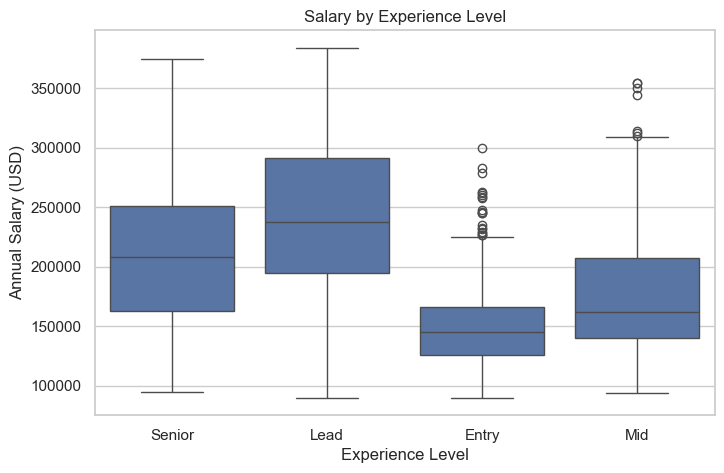

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df2,
    x="experience_level",
    y="annual_salary_usd"
)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Annual Salary (USD)")

plt.show()

### Salary Distribution by Experience Level

The boxplot illustrates the distribution of annual salaries across different experience levels, including Entry, Mid, Senior, and Lead roles.

A clear upward trend is observed as experience level increases. Entry-level roles have the lowest salary distribution, with a median significantly lower than all other groups. Mid-level roles show higher salaries than entry-level positions, while Senior and Lead roles exhibit the highest salary levels overall.

The median salary increases consistently across experience levels, indicating a strong positive relationship between experience and compensation. In particular, Lead roles have the highest median salaries, followed by Senior roles.

Additionally, the spread of salaries becomes wider for higher experience levels, especially for Senior and Lead positions. This suggests greater variability in compensation among more experienced roles, possibly due to differences in specialization, company size, or responsibilities.

Outliers are also more prominent in higher experience categories, indicating that some individuals in these roles earn significantly higher salaries.

Overall, the visualization provides strong evidence that salary increases with experience level, supporting the presence of salary inequality in the AI job market.

## AI Salary Premium Analysis

### Descriptive Statistics

In [3]:
df2.groupby("experience_level")["ai_salary_premium_pct"].agg(
    ["count", "mean", "std", "median", "min", "max"]
)

,count,mean,std,median,min,max
experience_level,,,,,,
Entry,385,10.761299,4.120273,10.2,3.1,18.0
Lead,381,10.691339,4.054712,10.2,3.1,17.9
Mid,370,11.060811,3.889246,10.6,3.0,18.0
Senior,364,10.929396,4.052906,11.1,3.0,17.9


### Descriptive Statistics for AI Salary Premium by Experience Level

The mean AI salary premium values are quite close to one another. Mid-level roles have the highest average premium at approximately 11.06%, followed by Senior roles at about 10.93%. Entry-level and Lead roles have slightly lower average premiums, around 10.76% and 10.69%, respectively.

The median values are also very similar across groups, ranging from 10.2% to 11.1%. This suggests that AI-related salary premiums do not vary dramatically by experience level at the descriptive level.

In addition, the standard deviations are close across all categories, indicating a similar spread of premiums within each group. The minimum and maximum values are also nearly the same, with premiums ranging from about 3% to 18%.

Overall, the descriptive statistics suggest that AI salary premiums are fairly similar across experience levels, with only small differences between groups.

## Visualization

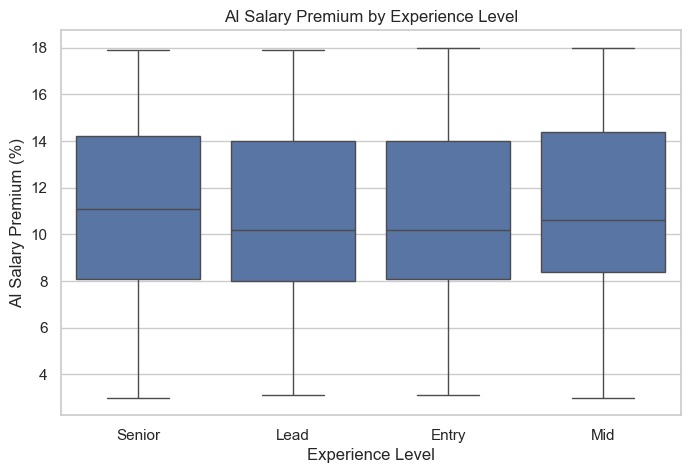

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df2,
    x="experience_level",
    y="ai_salary_premium_pct"
)

plt.title("AI Salary Premium by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("AI Salary Premium (%)")

plt.show()

### AI Salary Premium Distribution by Experience Level

Consistent with the descriptive statistics, the differences between groups are minimal. The median values for all experience levels are very close, generally ranging between approximately 10% and 11%. While Senior and Mid roles appear to have slightly higher median premiums than Entry and Lead roles, these differences are small and not visually substantial.

The spread of the data is also very similar across all groups. The interquartile ranges and overall ranges are nearly identical, with premiums typically ranging from about 3% to 18% for each experience level. This indicates that variability in AI-related compensation is consistent regardless of experience.

Unlike the salary distribution, which showed a clear increase with experience level, the AI salary premium does not display a strong upward trend. Instead, it appears to be relatively uniform across all groups.

Overall, the visualization suggests that AI salary premiums are distributed fairly evenly across experience levels. This indicates that, while general salary increases with experience, AI-related compensation does not disproportionately favor more experienced roles. 

## Statistical Testing with Welch ANOVA

In [5]:
from statsmodels.stats.oneway import anova_oneway

salary_groups = [
    df2[df2["experience_level"] == g]["annual_salary_usd"].values
    for g in df2["experience_level"].unique()
]

salary_test = anova_oneway(salary_groups, use_var="unequal")

print("Salary Test Result:")
print(salary_test)

Salary Test Result:
statistic = 213.67273015442038
pvalue = 7.735868263631712e-102
df = (3.0, np.float64(801.8813423943491))
df_num = 3.0
df_denom = 801.8813423943491
nobs_t = 1500.0
n_groups = 4
means = [214280.21978022 240055.11811024 150038.96103896 175983.78378378]
nobs = [364. 381. 385. 370.]
vars_ = [4.12730374e+09 4.72381159e+09 1.40040733e+09 2.65180461e+09]
use_var = unequal
welch_correction = True
tuple = (np.float64(213.67273015442038), np.float64(7.735868263631712e-102))


In [6]:
premium_groups = [
    df2[df2["experience_level"] == g]["ai_salary_premium_pct"].values
    for g in df2["experience_level"].unique()
]

premium_test = anova_oneway(premium_groups, use_var="unequal")

print("\nAI Premium Test Result:")
print(premium_test)


AI Premium Test Result:
statistic = 0.6563682205005059
pvalue = 0.5790838451056193
df = (3.0, np.float64(830.5616423180697))
df_num = 3.0
df_denom = 830.5616423180697
nobs_t = 1500.0
n_groups = 4
means = [10.9293956  10.69133858 10.7612987  11.06081081]
nobs = [364. 381. 385. 370.]
vars_ = [16.42604812 16.44068794 16.97664935 15.12623782]
use_var = unequal
welch_correction = True
tuple = (np.float64(0.6563682205005059), np.float64(0.5790838451056193))


### Hypothesis 2 Results and Interpretation

Welch’s ANOVA was conducted to examine whether salaries and AI-related salary premiums differ across experience levels.

The results show that salary differs significantly across experience levels (p < 0.05). Therefore, the null hypothesis for salary is rejected. This indicates that more experienced roles, such as Senior and Lead positions, earn substantially higher salaries compared to entry-level roles. This finding is consistent with the earlier descriptive statistics and visual analysis, which showed a clear upward trend in salary with increasing experience.

In contrast, the results for AI salary premium reveal no statistically significant difference across experience levels (p = 0.579 > 0.05). Therefore, the null hypothesis for AI salary premium cannot be rejected. This suggests that AI-related compensation is relatively similar across experience levels and does not vary significantly between entry-level and more experienced roles.

Taken together, these findings indicate that while salary inequality clearly exists in the AI job market, it is primarily driven by general experience-based compensation rather than AI-specific premiums. In other words, AI does not appear to disproportionately increase salary inequality, as the additional compensation associated with AI skills is distributed relatively evenly across experience levels.

This result provides an important insight: although experienced professionals earn higher overall salaries, the impact of AI-related compensation itself does not significantly favor more experienced roles.